In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload fan_3month_summer_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("fan_3month_summer_dataset.csv", parse_dates=["timestamp"])
df.head()


In [ ]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month


In [ ]:
features = ["hour", "day", "month", "temperature", "status", "rpm", "voltage", "current"]
X = df[features]
y = df["power_consumption"]


In [ ]:
split_index = int(len(df) * 0.83)  # ~75 days for training, 15 days for testing

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))


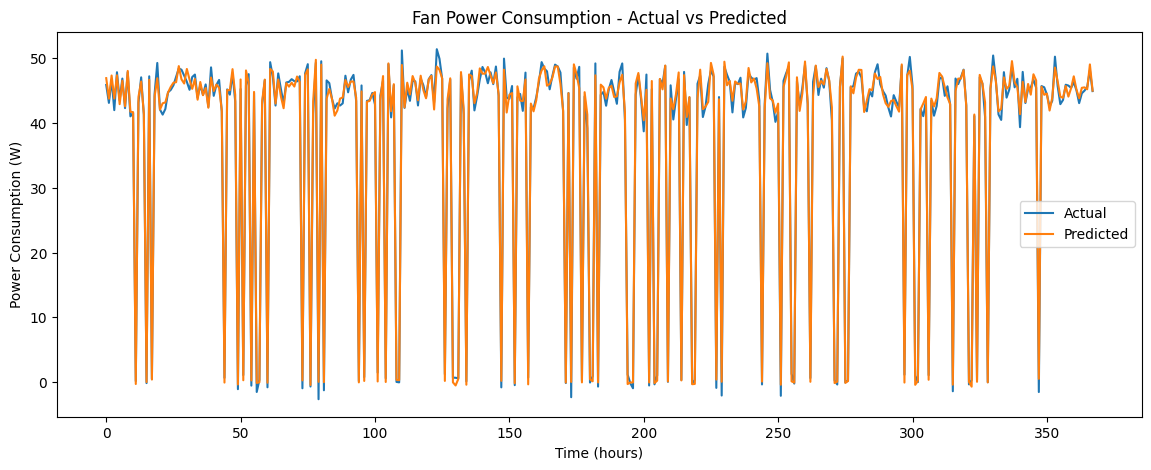

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Fan Power Consumption - Actual vs Predicted")
plt.xlabel("Time (hours)")
plt.ylabel("Power Consumption (W)")
plt.legend()
plt.show()


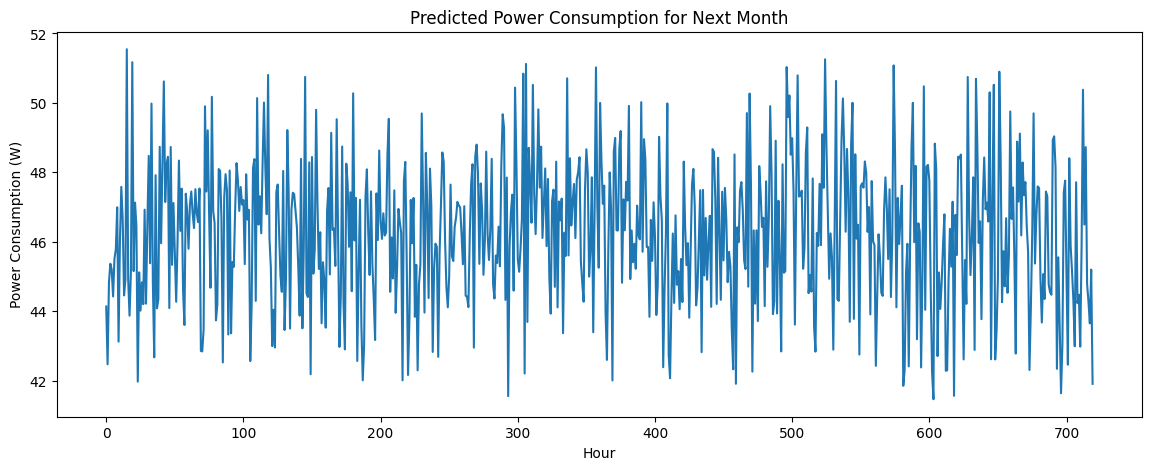

In [ ]:
from datetime import datetime, timedelta
import numpy as np

# Generate future timestamps
future_dates = [df["timestamp"].max() + timedelta(hours=i) for i in range(1, 24*30+1)]

# Simulate future input data
future_data = pd.DataFrame({
    "timestamp": future_dates,
    "hour": [t.hour for t in future_dates],
    "day": [t.day for t in future_dates],
    "month": [t.month for t in future_dates],
    "temperature": np.random.normal(loc=32, scale=1.5, size=24*30),  # summer
    "status": [1]*24*30,  # assume fan mostly ON
    "rpm": np.random.randint(1150, 1220, size=24*30),
    "voltage": np.random.normal(loc=220, scale=1.5, size=24*30),
    "current": np.random.normal(loc=0.21, scale=0.01, size=24*30)
})

# Predict
X_future = future_data[features]
future_predictions = model.predict(X_future)

# Add to DataFrame
future_data["predicted_power_consumption"] = future_predictions

# Plot future power consumption
plt.figure(figsize=(14, 5))
plt.plot(future_data["predicted_power_consumption"])
plt.title("Predicted Power Consumption for Next Month")
plt.xlabel("Hour")
plt.ylabel("Power Consumption (W)")
plt.show()


In [ ]:
from datetime import timedelta
import numpy as np
import pandas as pd

# Generate timestamps for next month (30 days * 24 hours = 720)
future_dates = [df["timestamp"].max() + timedelta(hours=i) for i in range(1, 24*30 + 1)]

# Simulate input values
future_data = pd.DataFrame({
    "timestamp": future_dates,
    "hour": [dt.hour for dt in future_dates],
    "day": [dt.day for dt in future_dates],
    "month": [dt.month for dt in future_dates],
    "temperature": np.random.normal(32, 1.5, 24*30),  # summer
    "status": [1] * (24*30),  # assuming fan is ON
    "rpm": np.random.randint(1150, 1220, 24*30),
    "voltage": np.random.normal(220, 2, 24*30),
    "current": np.random.normal(0.21, 0.01, 24*30)
})


In [ ]:
X_future = future_data[["hour", "day", "month", "temperature", "status", "rpm", "voltage", "current"]]
future_data["predicted_power_consumption"] = model.predict(X_future)


In [ ]:
# Total consumption over 1 month (in watt-hours)
total_wh = future_data["predicted_power_consumption"].sum()

# Convert to kilowatt-hours (1 kWh = 1000 Wh)
total_kwh = total_wh / 1000
print(f"Total Predicted Power Consumption for 1 Month: {total_kwh:.2f} kWh")


Total Predicted Power Consumption for 1 Month: 33.29 kWh


In [ ]:
unit_cost = 6.5  # You can change this as per your area
estimated_bill = total_kwh * unit_cost
print(f"Estimated Electricity Bill of fan for  1 Month: ₹{estimated_bill:.2f}")


Estimated Electricity Bill of fan for  1 Month: ₹216.40


In [ ]:
import joblib

joblib.dump(model, "fan_model.pkl")


['fan_model.pkl']

In [ ]:
from google.colab import files
files.download("fan_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv("fan_dataset.csv", index=False)
files.download("fan_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
future_data.to_csv("fan_next_month_prediction.csv", index=False)
files.download("fan_next_month_prediction.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Then save to /content/drive/MyDrive/


In [ ]:
!ls


In [ ]:
!zip -r smart-energy-manager.zip *


In [ ]:
from google.colab import files
files.download("smart-energy-manager.zip")
